<a href="https://colab.research.google.com/github/f1553508-cyber/AML-Final-Valiente-Celso/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🎓 Capstone Project - Deep Learning
## Programa de Especialización en Inteligencia Artificial para los Negocios

---

### 📋 Información del Proyecto

| Campo | Información |
|-------|-------------|
| **Nombre del Estudiante** | Celso Luis Valiente Morales|
| **Título del Proyecto** | Modelo Predictivo de Tamaño de Empresa |
| **Fecha de Entrega** | 16/03/2026|
| **Profesor** | Carlos Mariño|

Este notebook entrena modelos de Machine Learning y Deep Learning para **predecir el tamaño de una empresa**.

## 1. Importar librerías

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


## 2. Cargar dataset

In [7]:
df = pd.read_csv('dataset_empresas.csv')

# Si el dataset es muy grande, puedes activar esta línea para usar una muestra
# df = df.sample(200000, random_state=42)

df.head()

,UBIGEO,TAMANO,RANGO_VENTA,RANGO_TRABAJADOR,X1,Y1,CIIU
0,180101,Microempresa,[0 - 150],[0 - 5],-70.9357,-17.19270,5520
1,220701,Microempresa,[0 - 150],[0 - 5],-76.3311,-6.92216,5122
2,150117,Microempresa,[0 - 150],[0 - 5],-77.0841,-11.99820,5234
3,210101,Microempresa,[0 - 150],[0 - 5],-70.0237,-15.83870,6120
4,180101,Microempresa,[0 - 150],[0 - 5],-70.9367,-17.19300,5139


## 3. Preparación de datos

In [8]:
df_model = df[['UBIGEO', 'RANGO_VENTA', 'RANGO_TRABAJADOR', 'CIIU', 'TAMANO']].copy()

le_dict = {}
for col in df_model.columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le

X = df_model.drop('TAMANO', axis=1)
y = df_model['TAMANO']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (1346888, 4)
Test shape: (336722, 4)


## 4. Modelo Random Forest

In [9]:
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, pred_rf)

print('Accuracy Random Forest:', accuracy_rf)

Accuracy Random Forest: 1.0


## 5. Modelo Gradient Boosting

In [5]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)
accuracy_gb = accuracy_score(y_test, pred_gb)

print('Accuracy Gradient Boosting:', accuracy_gb)

Accuracy Gradient Boosting: 1.0


## 6. Modelo Deep Learning

In [10]:
model = Sequential()
model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(4, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
4210/4210 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9759 - loss: 0.2043 - val_accuracy: 0.9978 - val_loss: 0.0075
Epoch 2/20
4210/4210 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9968 - loss: 0.0220 - val_accuracy: 0.9985 - val_loss: 0.0047
Epoch 3/20
4210/4210 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9979 - loss: 0.0157 - val_accuracy: 0.9989 - val_loss: 0.0043
Epoch 4/20
4210/4210 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9986 - loss: 0.0097 - val_accuracy: 0.9995 - val_loss: 0.0018
Epoch 5/20
4210/4210 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9992 - loss: 0.0048 - val_accuracy: 0.9996 - val_loss: 0.0015
Epoch 6/20
4210/4210 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9989 - loss: 0.0110 - val_accuracy: 0.9997 - val_loss: 0.0010
Epoch 7/20
4210/4210 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9993 - loss: 0.0043 - val_accuracy: 1.0000 - val_loss: 7.6468e-04
Epoch 8/20
4210/4210 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9993 - los

### Gráfico de accuracy del entrenamiento

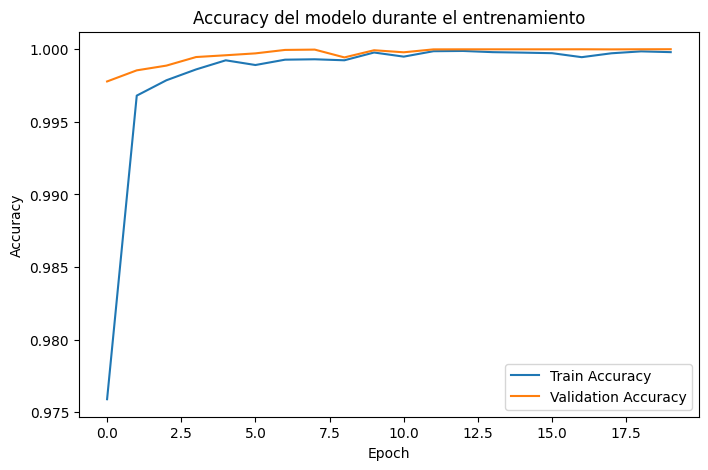

In [11]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy del modelo durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Gráfico de loss del entrenamiento

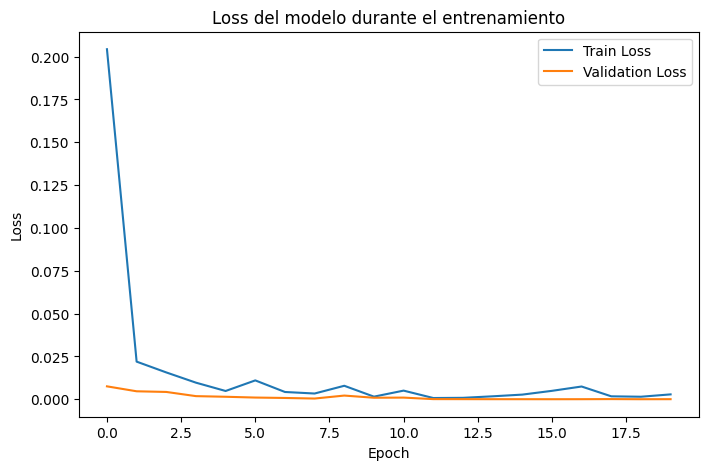

In [12]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss del modelo durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 7. Evaluación del modelo

In [13]:
loss, accuracy_dl = model.evaluate(X_test, y_test, verbose=0)
print('Accuracy Deep Learning:', accuracy_dl)
print('Loss Deep Learning:', loss)

Accuracy Deep Learning: 1.0
Loss Deep Learning: 5.344670353224501e-05


## 8. Resultados y métricas principales

In [14]:
y_pred_prob = model.predict(X_test, verbose=0)
y_pred_dl = y_pred_prob.argmax(axis=1)

print(classification_report(y_test, y_pred_dl))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1753
           1       1.00      1.00      1.00       542
           2       1.00      1.00      1.00    319936
           3       1.00      1.00      1.00     14491

    accuracy                           1.00    336722
   macro avg       1.00      1.00      1.00    336722
weighted avg       1.00      1.00      1.00    336722



### Matriz de confusión

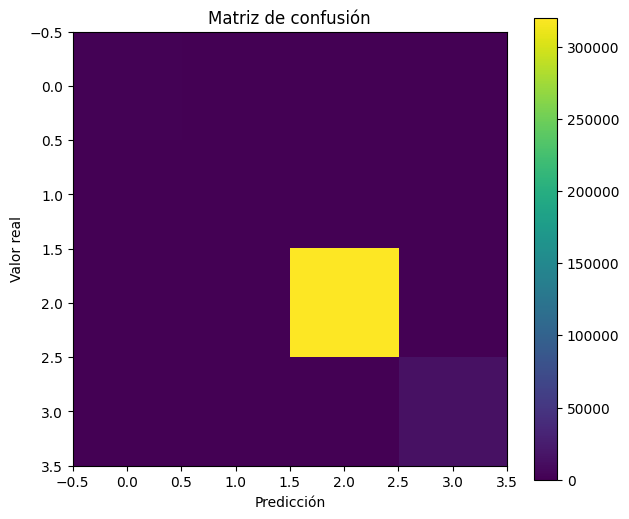

In [15]:
cm = confusion_matrix(y_test, y_pred_dl)

plt.figure(figsize=(7,6))
plt.imshow(cm)
plt.title('Matriz de confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.colorbar()
plt.show()

### Comparación visual de accuracy entre modelos

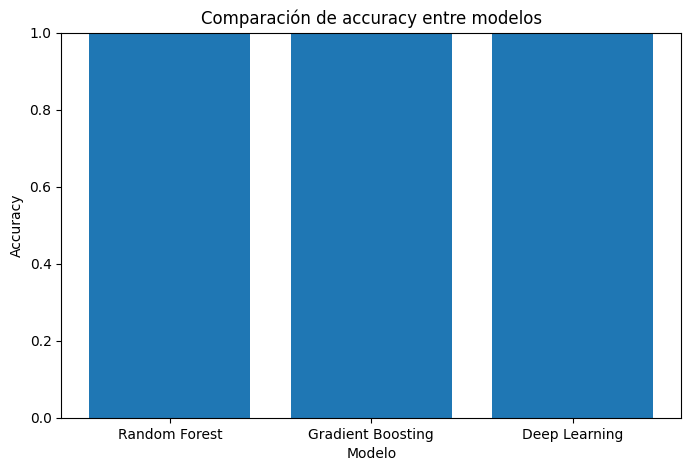

In [16]:
modelos = ['Random Forest', 'Gradient Boosting', 'Deep Learning']
accuracies = [accuracy_rf, accuracy_gb, accuracy_dl]

plt.figure(figsize=(8,5))
plt.bar(modelos, accuracies)
plt.title('Comparación de accuracy entre modelos')
plt.xlabel('Modelo')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

### Interpretación de métricas

- **Accuracy:** porcentaje total de empresas clasificadas correctamente.
- **Precision:** exactitud del modelo al predecir cada categoría.
- **Recall:** capacidad del modelo para identificar correctamente cada tipo de empresa.
- **F1 Score:** balance entre precision y recall.
- **Matriz de confusión:** permite visualizar en qué categorías el modelo se equivoca más.
